### Introducción

Mediante la ayuda de las herramientas con las que Python cuenta, se elaborará un proyecto en el que se analizará meidante latécnica Damodaran los estados de cuenta de la compañia NVIDIA, con el objetivo principal de determinar si su crecimiento en los últimos años ha sido justificado o si por el contrario ese crecimiento aparente se debe a la "burbuja de la IA" de la que se ha venido hablando en los últimos meses.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Definimos el Ticker
ticker_symbol ='NVDA'
empresa = yf.Ticker(ticker_symbol)

#DataFrame de yfinance dónde se ven los años y las cuentas contables
try:
    #Ganancias y perdidas
    income_stmt = empresa.financials
    #Activos y deudas 
    balance_sheet = empresa.balance_sheet
    #Dinero real y entrando y saliendo
    cahs_flow = empresa.cash_flow
except Exception as e:
    print(f'Error en la descarga: {e}')

#Verificación de descargar de los datos
print(f'Income Statement: {income_stmt.shape} (Cuentas por Años)')
print(f'Balance Shee: {balance_sheet.shape} (Cuentas por Años)')
print(f'Cash Flow: {cahs_flow.shape} (Cuentas por Años)')

#Previsualización del flujo de caja
display(cahs_flow.head(10))

Income Statement: (43, 4) (Cuentas por Años)
Balance Shee: (86, 5) (Cuentas por Años)
Cash Flow: (58, 5) (Cuentas por Años)


,2025-01-31,2024-01-31,2023-01-31,2022-01-31,2021-01-31
Free Cash Flow,6.085300e+10,2.702100e+10,3.808000e+09,8.132000e+09,NaN
Repurchase Of Capital Stock,-3.370600e+10,-9.533000e+09,-1.003900e+10,0.000000e+00,NaN
Repayment Of Debt,-1.250000e+09,-1.250000e+09,0.000000e+00,-1.000000e+09,NaN
Issuance Of Debt,NaN,0.000000e+00,0.000000e+00,4.977000e+09,4.968000e+09
Capital Expenditure,-3.236000e+09,-1.069000e+09,-1.833000e+09,-9.760000e+08,NaN
Interest Paid Supplemental Data,2.460000e+08,2.520000e+08,2.540000e+08,2.460000e+08,NaN
Income Tax Paid Supplemental Data,1.511800e+10,6.549000e+09,1.404000e+09,3.960000e+08,NaN
End Cash Position,8.589000e+09,7.280000e+09,3.389000e+09,1.990000e+09,NaN
Beginning Cash Position,7.280000e+09,3.389000e+09,1.990000e+09,8.470000e+08,NaN
Changes In Cash,1.309000e+09,3.891000e+09,1.399000e+09,1.143000e+09,NaN


Como se puede ver 2 de los 3 reportes empiezan desde el 2021 y una en el 2022 lo que generará problemas en el análisis previo si no se arregla ese problema.

In [3]:
#Obtenemos las columnas fechas de cada reporte
cols_income = income_stmt.columns
cols_balance = balance_sheet.columns
cols_cash = cahs_flow.columns

#Encontrar la Intersección de las fechas
common_years = cols_income.intersection(cols_balance).intersection(cols_cash)
print(f'Años encontrado en todo los reportes: {len(common_years)}')
print(common_years)

#Reescribir os Df tomando solo los años en común
income_stmt_aligned = income_stmt[common_years]
balance_sheet_aligned = balance_sheet[common_years]
cahs_flow_aligned = cahs_flow[common_years]

print(f'Income Statement: {income_stmt_aligned.shape}')
print(f'Balance_sheet: {balance_sheet_aligned.shape}')
print(f'cahs_flow: {cahs_flow_aligned.shape}')

Años encontrado en todo los reportes: 4
DatetimeIndex(['2025-01-31', '2024-01-31', '2023-01-31', '2022-01-31'], dtype='datetime64[ns]', freq='-1YE-JAN')
Income Statement: (43, 4)
Balance_sheet: (86, 4)
cahs_flow: (58, 4)


Ahora con la información recabada se creará un Dashboard para mnejar de manera más fácil a información.
* Total Revenue (Ventas)
* Net Income (Ganancia Neta)
* Free Cash Flow (Dinero en caja)
* Total Debt (Deuda)

In [4]:
analysis_data = {}
#Función para exraer datos de forma segura

def extract_row(df,row_name, label_for_table):
    try:
        #Intentamos buscar el nombre exacto
        analysis_data[label_for_table] = df.loc[row_name]
        print(f'{label_for_table} extraído correctamente')
    except KeyError:
        print(f' No se encontr: {row_name}')
        #Posibles sugerencias
        possibles_matches = [X for x in df.index if label_for_table.split()[0] in str(x)]
        print(f'Quizás quisiste decir: {possibles_matches[:3]}')

#Buscamos posibles palabras
extract_row(income_stmt_aligned, "Total Revenue", "Ingresos")
extract_row (income_stmt_aligned, "Net Income", "Utilidad Neta")
extract_row(cahs_flow_aligned, "Free Cash Flow", "FCF (Caja Libre)")
extract_row(balance_sheet_aligned, "Total Debt", "Deuda Total")

#Creamos el Df
df_analysis = pd.DataFrame(analysis_data)
df_analysis = df_analysis.T
display(df_analysis)


Ingresos extraído correctamente
Utilidad Neta extraído correctamente
FCF (Caja Libre) extraído correctamente
Deuda Total extraído correctamente


,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ingresos,1.304970e+11,6.092200e+10,2.697400e+10,2.691400e+10
Utilidad Neta,7.288000e+10,2.976000e+10,4.368000e+09,9.752000e+09
FCF (Caja Libre),6.085300e+10,2.702100e+10,3.808000e+09,8.132000e+09
Deuda Total,1.027000e+10,1.105600e+10,1.203100e+10,1.183100e+10


Se puede observar en el Df como los ingresos año con año van en aumento (el primer año creció poco, pero creció) de igual manera que lohace el FCF

In [5]:
df_plot = df_analysis.astype(float)
#Se invierte el orden para que el año más viejo esté a la izquierda
df_plot = df_plot.iloc[::-1]
plt.figure(figsize=(12,6))
plt.plot(df_plot.index, df_plot['Ingresos'], label='Ingresos (Revenue)', marker='o', linewidth=3)
plt.plot(df_plot.index, df_plot['FCF (Caja Libre)'], label='Cash Flow (Dinero Real)',marker ='s', linestyle='--', color='green')
plt.title('NVIDIA: ¿Crecimiento Real o Fachada (Ingresos vs Flujo de Caja)')
plt.xlabel('Año Fiscal', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Margen de Flujo de Caja: Por cada $100 que venden, ¿cuántos $ billetes reales se guardan?
# Si esto es bajo (menos de 0.10 o 10%), es un negocio débil
ultimo_ano = df_plot.index[-1]
margen_fcf = df_plot.loc[ultimo_ano, 'FCF (Caja Libre)'] / df_plot.loc[ultimo_ano, 'Ingresos']
print(f'Por cada $1.00 vendido NVIDIA se quedó con: ${margen_fcf:.2f} en efectivo libre.')

KeyError: 'Ingresos'

<Figure size 1200x600 with 0 Axes>

In [6]:
#No se encontraron los registros como supusimos vamos a buscar los posibles nombres que se guardaron
for nombre in income_stmt_aligned.index:
    if "Revenue" in str(nombre) or "Sales" in str(nombre):
        print(f'Encontrado: {nombre}')
    
print('\nNombre de la fila en Balance Sheet\n')
for nombre in balance_sheet_aligned.index:
    if "Debt" in str(nombre):
        print(f'Encontrado: {nombre}')

Encontrado: Reconciled Cost Of Revenue
Encontrado: Cost Of Revenue
Encontrado: Total Revenue
Encontrado: Operating Revenue

Nombre de la fila en Balance Sheet

Encontrado: Net Debt
Encontrado: Total Debt
Encontrado: Long Term Debt And Capital Lease Obligation
Encontrado: Long Term Debt
Encontrado: Current Debt And Capital Lease Obligation
Encontrado: Current Debt


 Ingresos extraídos de: Total Revenue
 Deuda extraída de: Total Debt
 No se halló 'Free Cash Flow'. Intentando calcularlo...
 FCF calculado manualmente (Operating Cash + Capex)

--- DATOS LISTOS PARA GRAFICAR ---


,Ingresos,Deuda Total,FCF (Caja Libre)
2022-01-31,2.691400e+10,1.183100e+10,8.132000e+09
2023-01-31,2.697400e+10,1.203100e+10,3.808000e+09
2024-01-31,6.092200e+10,1.105600e+10,2.702100e+10
2025-01-31,1.304970e+11,1.027000e+10,6.085300e+10


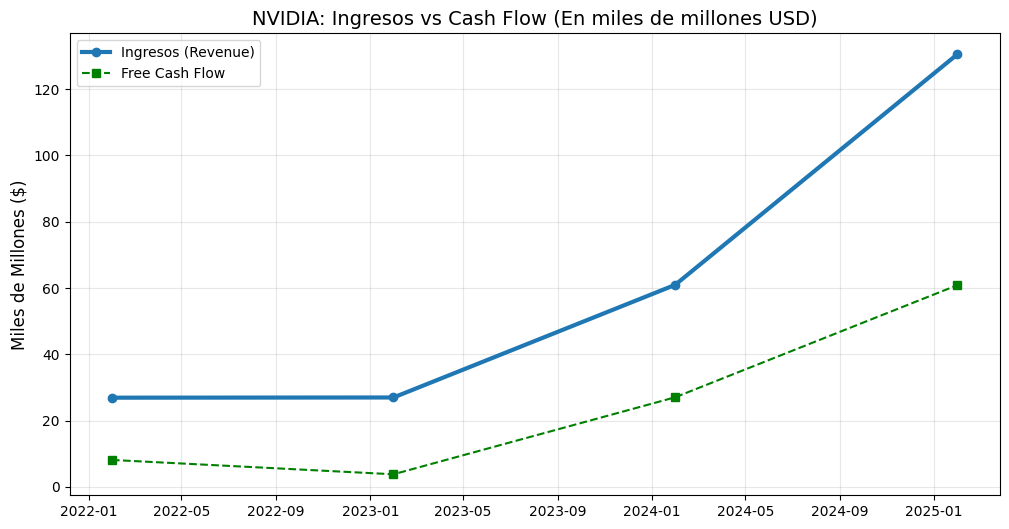

 RESULTADO FINAL DEL ANÁLISIS:
Por cada $1.00 de venta, NVIDIA genera $0.47 de flujo de caja libre.


In [7]:
# 1. DEFINICIÓN DE LOS NOMBRES EXACTOS (Los que tú encontraste)
# Si alguno falla, cambia el texto entre comillas aquí mismo.
row_revenue = 'Total Revenue'      # Encontrado en Income Statement
row_debt    = 'Total Debt'         # Encontrado en Balance Sheet
row_income  = 'Net Income'         # (Estándar) En Income Statement
row_fcf     = 'Free Cash Flow'     # (Estándar) En Cash Flow

# 2. EXTRACCIÓN MANUAL (Sin funciones complejas, directo al grano)
datos = {}


# Extracción de Ingresos
try:
    datos['Ingresos'] = income_stmt_aligned.loc[row_revenue]
    print(f" Ingresos extraídos de: {row_revenue}")
except KeyError:
    print(f" Error en Ingresos: No existe la fila '{row_revenue}'")

# Extracción de Deuda
try:
    datos['Deuda Total'] = balance_sheet_aligned.loc[row_debt]
    print(f" Deuda extraída de: {row_debt}")
except KeyError:
    print(f" Error en Deuda: No existe la fila '{row_debt}'")

# Extracción de FCF
try:
    datos['FCF (Caja Libre)'] = cahs_flow_aligned.loc[row_revenue]
    print(f" FCF extraído de: {row_fcf}")
except KeyError:
    # Plan B si falla el nombre estándar
    print(f" No se halló '{row_fcf}'. Intentando calcularlo...")
    # FCF = Flujo Operativo - CAPEX
    op_cash = cahs_flow_aligned.loc['Operating Cash Flow']
    capex = cahs_flow_aligned.loc['Capital Expenditure']
    datos['FCF (Caja Libre)'] = op_cash + capex # Capex suele ser negativo
    print(" FCF calculado manualmente (Operating Cash + Capex)")

# 3. CREACIÓN DEL DATAFRAME
df_final = pd.DataFrame(datos)
# IMPORTANTE: No transponemos si ya lo armamos así, o validamos la forma.
# Verificamos si las fechas son el índice o las columnas.
if isinstance(df_final.index, pd.DatetimeIndex) or '202' in str(df_final.index[0]):
    pass # Ya está bien (Años en las filas)
else:
    df_final = df_final.T # Invertimos si es necesario

# Ordenamos por fecha (del más viejo al más nuevo) para que el gráfico salga bien
df_final = df_final.sort_index(ascending=True)

print("\n--- DATOS LISTOS PARA GRAFICAR ---")
display(df_final.tail()) # Mostramos los últimos años

# 4. GRAFICAR (Aquí mismo para evitar errores de celda)
plt.figure(figsize=(12, 6))

# Convertimos a float por si acaso y dividimos entre 1 Billón (1e9) para leer mejor
df_plot = df_final.astype(float) / 1e9 

plt.plot(df_plot.index, df_plot['Ingresos'], label='Ingresos (Revenue)', marker='o', linewidth=3)
plt.plot(df_plot.index, df_plot['FCF (Caja Libre)'], label='Free Cash Flow', marker='s', linestyle='--', color='green')

plt.title(f'NVIDIA: Ingresos vs Cash Flow (En miles de millones USD)', fontsize=14)
plt.ylabel('Miles de Millones ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5. EL DATO DE LA VERDAD
last_revenue = df_plot['Ingresos'].iloc[-1]
last_fcf = df_plot['FCF (Caja Libre)'].iloc[-1]
margin = last_fcf / last_revenue

print(f" RESULTADO FINAL DEL ANÁLISIS:")
print(f"Por cada $1.00 de venta, NVIDIA genera ${margin:.2f} de flujo de caja libre.")

El análisis histórico revela una correlación estrecha entre Ingresos y Flujo de Caja Libre (FCF) hasta el Q1-2024. A partir de este punto, se observa una divergencia: aunque los ingresos crecen exponencialmente, la pendiente del FCF es ligeramente menor, indicativo de un aumento necesario en CAPEX (reinversión en infraestructura) para sostener la demanda.

El margen de eficiencia de $0.47 por dólar confirma una solvencia estructural extraordinaria, lo cual descarta una 'Burbuja de Insolvencia' (tipo esquema Ponzi o empresa fantasma). Sin embargo, esto no elimina el riesgo de una 'Burbuja de Valuación' (precio de mercado despegado del valor real). La sostenibilidad de estos márgenes a largo plazo es la variable crítica a despejar mediante el modelo de valuación."

1. El Concepto Central: El Valor del Dinero en el TiempoEl principio fundamental de este análisis es que un dólar hoy vale más que un dólar mañana, debido a su capacidad potencial de generar rendimientos (intereses).Por lo tanto, para saber cuánto vale realmente una empresa hoy, no podemos simplemente sumar el dinero que ganará en el futuro. Debemos "descontar" (reducir) esos flujos futuros para traerlos a su valor presente equivalente.La fórmula base que utilizaremos es:$$Valor = \sum_{t=1}^{n} \frac{FCF_t}{(1 + WACC)^t}$$Donde:$FCF_t$ (Free Cash Flow): Es el efectivo real que la empresa genera en un año específico (después de pagar gastos e inversiones).$WACC$ (Tasa de Descuento): Es el porcentaje que usamos para ajustar el valor del dinero por el riesgo y el tiempo.
2. WACC: El Costo Promedio Ponderado de CapitalUna empresa se financia de dos formas: pidiendo dinero prestado (Deuda) o recibiendo dinero de inversionistas (Patrimonio/Equity). Ambas fuentes tienen un costo. El WACC es el promedio de estos costos.Si el WACC es del 10%, significa que la empresa debe generar un retorno de al menos el 10% anual solo para satisfacer a sus acreedores y accionistas.El cálculo se compone de dos partes:A. Costo del Patrimonio ($K_e$) - Modelo CAPMRepresenta el retorno mínimo que exigen los accionistas por invertir su dinero en la empresa, considerando el riesgo que corren. Se calcula sumando tres factores:$$K_e = R_f + \beta (R_m - R_f)$$Tasa Libre de Riesgo ($R_f$): Es el rendimiento base de una inversión "segura" (usualmente Bonos del Tesoro de EE.UU.).Beta ($\beta$): Mide qué tan volátil es la acción comparada con el mercado general.Si $\beta > 1$: La acción es más riesgosa que el promedio (sube y baja con fuerza).Si $\beta < 1$: La acción es más estable que el promedio.Prima de Riesgo de Mercado ($R_m - R_f$): Es el rendimiento extra promedio que ofrece la bolsa de valores sobre los bonos seguros.B. Costo de la Deuda ($K_d$)Es la tasa de interés que la empresa paga actualmente por sus préstamos bancarios y bonos corporativos.

3. Proyección de Crecimiento (Forecasting)Para estimar cuánto dinero generará la empresa en el futuro, utilizamos tasas de crecimiento basadas en datos históricos:CAGR (Tasa de Crecimiento Anual Compuesto): Calcula la velocidad promedio a la que han crecido los flujos de caja en los últimos años. Usaremos este dato para proyectar los primeros 5 años.Valor Terminal: Para los años lejanos (después del año 5), asumimos que la empresa crecerá a un ritmo estable y perpetuo alineado con la economía global (ej. 2% - 3%).

4. Veredicto: Valor Intrínseco vs. Precio de MercadoEl objetivo final del algoritmo es calcular el Valor Intrínseco por Acción (el valor real matemático) y compararlo con el precio actual en la bolsa.Valor Intrínseco > Precio Actual: La acción está Subvaluada (Es una oportunidad de compra, el mercado no ha reconocido su valor real).Valor Intrínseco < Precio Actual: La acción está Sobrevaluada (Es riesgoso comprar, el precio está inflado por expectativas o especulación).

INICIO DEL ALGORITMO

    // --- DEFINICIÓN DE CONSTANTES (Valores Estándar del Mercado) ---
    DEFINIR Tasa_Impuestos = 0.21       (21% es el estándar corporativo en USA)
    DEFINIR Prima_Riesgo_Mercado = 0.05 (5% es el premio histórico por invertir en bolsa)

    // --- FASE 1: OBTENCIÓN DE DATOS EXTERNOS (Inputs) ---
    OBTENER de YahooFinance: "Tasa_Bono_Tesoro_10_Años" (Variable: Rf)
    OBTENER de YahooFinance: "Beta_NVIDIA"              (Variable: Beta)
    OBTENER de YahooFinance: "Market_Cap"               (Valor total de las acciones hoy)
    OBTENER de Reporte_Financiero: "Deuda_Total"        (Lo que debe al banco)
    OBTENER de Reporte_Financiero: "Gasto_Intereses"    (Lo que pagó de intereses el último año)

    // --- FASE 2: CÁLCULO DEL COSTO DE EQUITY (Dinero de los Socios) ---
    // Usamos el Modelo CAPM: Base Segura + (Riesgo * Premio)
    
    CALCULAR Costo_Equity = Rf + (Beta * Prima_Riesgo_Mercado)

    // --- FASE 3: CÁLCULO DEL COSTO DE DEUDA (Dinero del Banco) ---
    // Primero calculamos la tasa bruta que cobra el banco
    
    SI (Deuda_Total > 0 Y Gasto_Intereses > 0) ENTONCES:
        Tasa_Interes_Banco = Gasto_Intereses / Deuda_Total
    SINO:
        // Si no hay datos, estimamos un costo base
        Tasa_Interes_Banco = Rf + 0.015 
    FIN SI

    // Ajustamos por el beneficio fiscal (Tax Shield)
    CALCULAR Costo_Deuda_Neto = Tasa_Interes_Banco * (1 - Tasa_Impuestos)

    // --- FASE 4: PONDERACIÓN (La Mezcla de Concreto) ---
    // Calculamos cuánto pesa cada fuente de dinero en la estructura total
    
    CALCULAR Valor_Total_Empresa = Market_Cap + Deuda_Total
    
    CALCULAR Peso_Equity = Market_Cap / Valor_Total_Empresa
    CALCULAR Peso_Deuda  = Deuda_Total / Valor_Total_Empresa

    // --- FASE 5: RESULTADO FINAL (Promedio Ponderado) ---
    
    CALCULAR WACC = (Peso_Equity * Costo_Equity) + (Peso_Deuda * Costo_Deuda_Neto)

    RETORNAR WACC (Este es el porcentaje final)

FIN DEL ALGORITMO

In [8]:
# 1. DEFINICIÓN DE CONSTANTES (Parámetros Fijos)
# Tasa de impuesto corporativo en USA (Tax Rate). Necesaria para el beneficio fiscal de la deuda.
TAX_RATE = 0.21

# Prima de Riesgo de Mercado (Market Risk Premium).
# Es el retorno extra promedio que paga la bolsa sobre los bonos (Históricamente ~5%)
MARKET_PREMIUM = 0.05

# Descargamos el diccionario 'info' que contiene Beta, Deuda y Market Cap
# (Esto puede tardar unos segundos dependiendo de tu internet)
info = empresa.info

# 3. EXTRACCIÓN DE VARIABLES (Con seguridad)

# A) Beta (Volatilidad)
# Si no encuentra el dato, asumimos 1.0 (que significa riesgo promedio igual al mercado)
beta = info.get('beta',1)

# B) Market Cap (Valor total de las acciones hoy)
market_cap = info.get('marketCap',0)

# C) Deuda Total (Dinero que le deben al banco)
total_debt = info.get('totalDebt',0)

# D) Gasto de Intereses (Cuánto pagaron de intereses el último año)
try:
    # Buscamos en el Estado de Resultados ('financials')
    # Usamos abs() porque contablemente suele venir como número negativo
    interest_expense = abs(empresa.financials.loc['Interest Expense'].iloc[0])
except:
    # Si falla la lectura, asumimos 0 por ahora
    interes_expense = 0
    print('Nota: No se encontró el gaso exacto de intereses.')
    

# E) Tasa Libre de Riesgo (Risk Free Rate)
# Descargamos el rendimiento del Bono del Tesoro a 10 años (Ticker: ^TNX)
try:
    tnx = yf.Ticker('^TNX')
    # Tomamos el último valor de cierre y dividimos entre 100 (4.5% -> 0.045)
    risk_free_rate =tnx.history(period='5d')['Close'].iloc[-1]/100
except:
    # Fallback de seguridad (4.2%)
    risk_free_rate = 0.042
# --- VERIFICACIÓN (Imprimimos para ver que todo llegó bien) ---
print(f'-Tasa Libre de Riesgo: {risk_free_rate:.2f}%')
print(f'-Beta: {beta:.2f}')
print(f'-Deuda Total: ${total_debt:,.0f}')
print(f'-Market Cap: {market_cap:,.0f}')

-Tasa Libre de Riesgo: 0.04%
-Beta: 2.28
-Deuda Total: $10,821,999,616
-Market Cap: 4,292,132,732,928


In [9]:

# --- FASE 2: COSTO DEL EQUITY (Ke) ---
# Fórmula CAPM: Base + (Riesgo * Premio)
# Lógica: Si Beta es 2.0, exigimos el doble de premio que al mercado general.
cost_of_equity = risk_free_rate + (beta * MARKET_PREMIUM)
print(f'Costo del Equity (Ke): {cost_of_equity:.2f}')
print('Los accionista exigen ganar esto anualmente')
# --- FASE 3: COSTO DE DEUDA NETO (Kd) ---

# Primero calculamos la tasa bruta (Lo que cobra el banco antes de impuestos)
if total_debt >0 and interest_expense>0:
    cost_of_debt_gross = interest_expense/total_debt
else:
    # Si no hay deuda o datos, asumimos un spread pequeño (1.5%) sobre la base
    cost_of_debt_gross = risk_free_rate + 0.015
    print('Usando estimación para el costo de deuda')

# Aplicamos el Escudo Fiscal (Tax Shield)
# Multiplicamos por (1 - 0.21) -> Es decir, nos quedamos con el 79% del costo
cost_of_debt_net = cost_of_debt_gross * (1-TAX_RATE)

print(f'Costo de Deuda Neto (Kd): {cost_of_debt_net:.2f}%')
print('Esto cuesta el dinero del banco después de beneficios fiscales')

Costo del Equity (Ke): 0.16
Los accionista exigen ganar esto anualmente
Costo de Deuda Neto (Kd): 0.02%
Esto cuesta el dinero del banco después de beneficios fiscales


In [10]:
# --- FASE 4: ESTRUCTURA DE CAPITAL (PESOS) ---

# 1. Valor Total de la Empresa (Enterprise Value aproximado para WACC)
total_value = market_cap + total_debt

# 2. Calculamos los porcentajes (Pesos)
weight_equity = market_cap/total_value
weight_debt = total_debt/total_value

print(f'-Peso del Equity (Socio): {weight_equity:.5f}%')
print(f'-Peso de la Deuda: {weight_debt:.5f}%')
print(f'-La suma debe ser 100%: {weight_debt+weight_equity:.4f}%')
# --- FASE 5: CÁLCULO FINAL DEL WACC ---
# Fórmula del Promedio Ponderado
wacc = (weight_equity*cost_of_equity) + (weight_debt*cost_of_debt_net)
print(f'WACC final calculado: {wacc:.2f}%')
print('Interpretación')
print(f'El dinero futuro de NVIDIA perderá un {wacc:.2f}% de su valor cada año que pase.')

-Peso del Equity (Socio): 0.99748%
-Peso de la Deuda: 0.00252%
-La suma debe ser 100%: 1.0000%
WACC final calculado: 0.16%
Interpretación
El dinero futuro de NVIDIA perderá un 0.16% de su valor cada año que pase.


## CAGR

El siguiente paso es calcular el CAGR (Tasa de Crecimiento Anual Compuesto). Esta métrica representa la velocidad de crecimiento constante necesaria para ir del valor inicial al valor final, 'suavizando' la volatilidad de los años intermedios. Su objetivo es darnos una base histórica realista para proyectar los flujos de efectivo futuros en nuestro modelo

INICIO DEL PROCESO

    // 1. OBTENER DATOS
    // Necesitamos la lista de "Free Cash Flow" que ya limpiamos previamente.
    // La lista debe estar ordenada del año más viejo al más actual.
    
    OBTENER Lista_FCF
    
    // 2. IDENTIFICAR PUNTOS CLAVE
    // Tomamos el primer dato (hace 4 o 5 años)
    Valor_Inicial = Lista_FCF[Posición_0] 
    
    // Tomamos el último dato (año actual/reciente)
    Valor_Final   = Lista_FCF[Última_Posición]
    
    // 3. CONTAR EL TIEMPO
    // Los "saltos" son la cantidad de años menos 1.
    // Ejemplo: Si hay datos de 2020, 2021, 2022, 2023 (4 datos), hay 3 periodos de crecimiento.
    Numero_Años = Contar(Lista_FCF) - 1
    
    // 4. APLICAR FÓRMULA MATEMÁTICA
    // (Final / Inicial) elevado a la (1 / Años) - 1
    
    CAGR = (Valor_Final / Valor_Inicial) ^ (1 / Numero_Años) - 1
    
    // 5. RESULTADO
    // Guardamos este porcentaje. Será nuestra "Tasa de Crecimiento (g)" para la proyección.
    RETORNAR CAGR

FIN DEL PROCESO

In [11]:
# 1. Obtener los datos (De la tabla que ya teníamos 'cash_flow_aligned')
try:
    # Extraemos solo la fila de "Free Cash Flow"
    # IMPORTANTE: Los invertimos [::-1] para que vaya de Pasado -> Presente
    fcf_history = cahs_flow_aligned.loc['Free Cash Flow'].iloc[::-1]
    # 2. Definir Puntos de Inicio y Fin
    fcf_initial = fcf_history.iloc[0]    # El dato más antiguo (ej. 2021)
    fcf_final = fcf_history.iloc[-1]    # El dato más reciente (ej. 2024/25)
    
    # 3. Contar los periodos (Años - 1)
    years_count = len(fcf_history) -1
    
    print(f'-FCF Inicial ({fcf_history.index[0]}): ${fcf_initial:.2f}')
    print(f'-FCF Final ({fcf_history.index[-1]}): ${fcf_final:.2f}')

    # 4. Fórmula Matemática del CAGR
    # (Valor Final / Valor Inicial) ^ (1 / n) - 1
    cagr = (fcf_final/fcf_initial) ** (1/years_count) -1
    print(f'Velocidad de crecimiento (CAGR): {cagr:.2f}%')
except Exception as e:
    print(f'Error: {e}')

-FCF Inicial (2022-01-31 00:00:00): $8132000000.00
-FCF Final (2025-01-31 00:00:00): $60853000000.00
Velocidad de crecimiento (CAGR): 0.96%


El parámetro CAGR nos dice que anualmente en los últimos 3 años la empresa NVIDIA ha crecido un 96% por año (Duplicado su valor año con año). A lo largo esto es insostenible por lo que para predecir algo realista se tomará un 35% como parámetro. Tomando el crecimiento en 35% debido a que 96% es insostenible para cualquier empresa calcularemos el crecimiento para los próximos 5 años, una vez pasamos ese tiempo el crecimiento se calculará mediante otro método.

INICIO DEL PROCESO

    // 1. CONFIGURACIÓN INICIAL
    DEFINIR Tasa_Crecimiento = 0.35    (Nuestro 35% acordado)
    DEFINIR Proyecciones = [Lista Vacía]
    
    // Obtenemos el punto de partida (El último dato real que tenemos)
    OBTENER Ultimo_FCF_Conocido 
    
    VARIABLE FCF_Acumulado = Ultimo_FCF_Conocido

    // 2. EL CICLO DE CRECIMIENTO (Loop)
    // Repetir para Año 1, Año 2, Año 3, Año 4, Año 5
    
    PARA i DESDE 1 HASTA 5 HACER:
    
        // A) Calculamos el nuevo monto compuesto
        //    Fórmula: Monto_Anterior * (1 + Tasa)
        Nuevo_FCF = FCF_Acumulado * (1 + Tasa_Crecimiento)
        
        // B) Guardamos el resultado en la lista
        AGREGAR Nuevo_FCF a la lista Proyecciones
        
        // C) Actualizamos el acumulado para la siguiente vuelta
        //    (Esto es clave: el año 2 se basa en el resultado del año 1)
        FCF_Acumulado = Nuevo_FCF

    FIN PARA

    // 3. RESULTADO
    IMPRIMIR Lista Proyecciones
    // Deberíamos tener 5 montos, cada uno más grande que el anterior

FIN DEL PROCESO

In [12]:
# 1. PARAMETROS DE ENTRADA
# Criterio de Ingeniería: 35% (Manual)
# Proyectamos 5 años de alto crecimiento
GROWTH_RATE_PROJ = 0.35
YEARS_PROJECTION = 5


# Recuperamos el último dato real conocido (Año 0)
# (Usamos la variable fcf_final del paso anterior)
last_fcf_known = fcf_final
print(f'Punto de Partida: {last_fcf_known}')



# 2. BUCLE DE PROYECCIÓN (La bola de nieve)
future_fcf = []
current_fcf = last_fcf_known

for i in range(1, YEARS_PROJECTION + 1):
    # A) Aplicamos el interés compuesto
    # Nuevo = Anterior * (1 + 0.35)
    current_fcf = current_fcf * (1+ GROWTH_RATE_PROJ)
    
    # B) Guardamos en la lista
    future_fcf.append(current_fcf)
    

# 3. CREAMOS UNA TABLA LIMPIA (Para uso futuro)
# Convertimos la lista en un DataFrame para manipularlo fácil después
projection_df = pd.DataFrame({
    'Year':range(1, YEARS_PROJECTION + 1),
    'Projected_FCF':future_fcf
})

print(projection_df)

Punto de Partida: 60853000000.0
   Year  Projected_FCF
0     1   8.215155e+10
1     2   1.109046e+11
2     3   1.497212e+11
3     4   2.021236e+11
4     5   2.728669e+11


Con estos valores es momento de calcular el crecimiento a partir del 6to año


INICIO DEL PROCESO

    // 1. DEFINIR VARIABLES
    // Recuperamos variables que ya tenemos en la mochila
    WACC = 0.16             (Calculado en Fase 1)
    FCF_Año_5 = [Ultimo valor de la lista de proyecciones]
    
    // Definimos el crecimiento perpetuo (estable)
    // Usamos 3% (0.03) que es similar al crecimiento de la economía mundial/inflación
    Tasa_Perpetua = 0.03    

    // 2. CALCULAR EL PRIMER AÑO DE LA PERPETUIDAD (AÑO 6)
    // La fórmula necesita el flujo del año siguiente al periodo de proyección
    FCF_Año_6 = FCF_Año_5 * (1 + Tasa_Perpetua)

    // 3. APLICAR FÓRMULA DE GORDON
    // Valor = Flujo Año 6 / (Tasa Descuento - Tasa Crecimiento)
    // OJO: El WACC funciona como la gravedad que atrae el valor a la tierra.
    
    Valor_Terminal = FCF_Año_6 / (WACC - Tasa_Perpetua)

    // 4. RESULTADO
    IMPRIMIR Valor_Terminal
    // Este número será GIGANTE, porque representa todo el dinero de aquí al fin de los tiempos.

FIN DEL PROCESO

In [13]:
# 1. PARAMETROS
PERPETUAL_RATE = 0.03

# 2. OBTENER EL ÚLTIMO DATO DE LA PROYECCIÓN (AÑO 5)
# Usamos .iloc[-1] para ir al último renglón de la columna 'Projected_FCF' del paso anterior
last_fcf_projected = projection_df['Projected_FCF'].iloc[-1]

# 3. APLICAR FÓRMULA DE GORDON (El valor del futuro lejano)
# Numerador: Flujo del Año 6 (que es Año 5 * 1.03)
# Denominador: La diferencia entre Riesgo y Crecimiento (WACC - Tasa)
terminal_value = (last_fcf_projected * (1 + PERPETUAL_RATE))/ (wacc-PERPETUAL_RATE)

print(f'Valor terminal calculado: ${terminal_value:.2f}')

Valor terminal calculado: $2236383233910.61


### 🧠 Concepto Clave: Flujo de Caja Proyectado (Año 5) vs. Valor Terminal

Es fundamental distinguir los dos componentes de valor que convergen al final del periodo de proyección (Año 5), ya que representan flujos de naturaleza distinta:

1.  **Flujo de Caja Libre Proyectado (Año 5):**
    * Representa exclusivamente el efectivo operativo generado por la empresa **durante** el quinto año.
    * Es el resultado final de la fase de alto crecimiento (Tasa del 35%).

2.  **Valor Terminal:**
    * Representa el valor presente (situado en el Año 5) de todos los flujos de efectivo futuros que la empresa generará desde el **Año 6 hasta perpetuidad**.
    * Se calcula asumiendo que la empresa entra en una fase de madurez con crecimiento estable (Modelo de Gordon).

**Nota Técnica Importante:**
Matemáticamente, ambos montos (el flujo del año 5 y el valor de la perpetuidad) se sitúan en la línea de tiempo en el horizonte $t=5$.
Por lo tanto, para determinar el valor intrínseco actual de la acción, el siguiente paso mandatorio es **descontar ambos valores** a su Valor Presente ($t=0$) utilizando la tasa WACC como factor de descuento.

### Fase 5: Cálculo del Precio Intrínseco por Acción

El **Enterprise Value** calculado anteriormente representa el valor de todo el negocio operativo. Para obtener el valor que corresponde a los accionistas (Equity Value) y finalmente el precio por acción, debemos realizar el **Ajuste Patrimonial**:

$$Equity Value = Enterprise Value + Caja Total - Deuda Total$$

Para esto, utilizaremos los datos reales del último reporte trimestral de NVIDIA:
1.  **Cash & Equivalents:** Efectivo y liquidez inmediata (Suma valor).
2.  **Total Debt:** Deuda financiera con acreedores (Resta valor).
3.  **Shares Outstanding:** Número de acciones para dividir el pastel.

INICIO DEL PROCESO

    // 1. RECUPERAR EL RESULTADO ANTERIOR
    Variable Enterprise_Value = [Resultado del Descuento de Flujos]

    // 2. DEFINIR DATOS DEL BALANCE GENERAL (Inputs Reales)
    // Estos son datos duros, no proyecciones
    Caja_Total 
    Deuda_Total
    Numero_Acciones

    // 3. CALCULAR EQUITY VALUE (Valor Patrimonial)
    // Sumamos lo que tienen, restamos lo que deben
    Equity_Value = Enterprise_Value + Caja_Total - Deuda_Total

    // 4. CALCULAR PRECIO POR ACCIÓN INDIVIDUAL
    // Repartimos el pastel entre todos los accionistas
    Precio_Objetivo = Equity_Value / Numero_Acciones

    // 5. RESULTADO FINAL
    IMPRIMIR Precio_Objetivo
    // Este es el precio que compararemos con Google Finance

FIN DEL PROCESO


In [14]:
# 1. OBTENER VARIABLES CLAVE (Balance Sheet)
# .get() es seguro: si no encuentra el dato, devuelve 0 en lugar de error
cash_and_equivalents = info.get('totalCash',0)
total_debt = info.get('total_Debt',0)
shares_outstanding = info.get('sharesOutstanding',1)    # Evitamos división por cero
market_price_now = info.get('currentPrice',0)

print(f'-Caja Total: ${cash_and_equivalents:,.2f}')
print(f'-Deuda total: ${total_debt:,.2f}')
print(f'-Acciones (Cant.): {shares_outstanding:,.2f}')
print(f'-Precio Mercado Hoy: ${market_price_now:.2f}')

# 2. CÁLCULO DEL EQUITY VALUE
# Enterprise Value (del paso anterior) + Caja - Deuda
equity_value = terminal_value + cash_and_equivalents - total_debt
print(f'Enterprise Value (Calculado): ${terminal_value:,.2f}')
print(f'Equity Value (Patrimonio): ${equity_value:,.2f}')

# 3. PRECIO INTRÍNSECO POR ACCIÓN (TARGET PRICE)
intrinsic_value = equity_value/shares_outstanding
print(f'Precio justo calculado: ${intrinsic_value:.2f}')
print(f'Precio Actual Mercado: ${market_price_now:.2f}')
# 4. VEREDICTO AUTOMÁTICO
upside = (intrinsic_value - market_price_now)/ market_price_now

if intrinsic_value > market_price_now:
    print(f'Conclusión: Subvaluada (Oportunidad de {upside:.1f}%)')
    print('El modelo sugiere que la acción vale más de lo que cuesta hoy.')
elif intrinsic_value < market_price_now:
    print(f'Conclución Sobrevaluada (Riesgo de {upside:.1f}%)')
    print('El modelo sugiere que la acción está cara actualmente.')
else:
    print('Conclusión Precio Justo')

-Caja Total: $60,608,000,000.00
-Deuda total: $0.00
-Acciones (Cant.): 24,305,000,000.00
-Precio Mercado Hoy: $176.29
Enterprise Value (Calculado): $2,236,383,233,910.61
Equity Value (Patrimonio): $2,296,991,233,910.61
Precio justo calculado: $94.51
Precio Actual Mercado: $176.29
Conclución Sobrevaluada (Riesgo de -0.5%)
El modelo sugiere que la acción está cara actualmente.


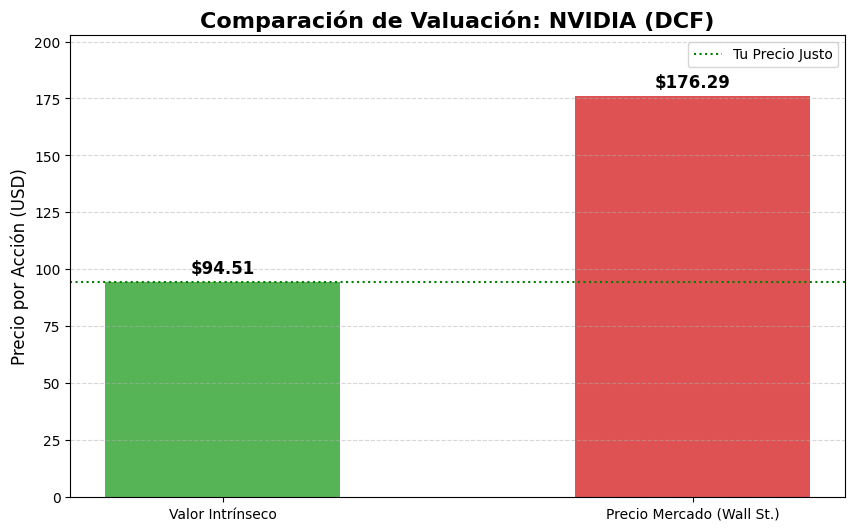

In [17]:
import matplotlib.pyplot as plt

# 1. PREPARAR DATOS
labels = ['Valor Intrínseco', 'Precio Mercado (Wall St.)']
values = [intrinsic_value, market_price_now]

# Colores: Verde para tu cálculo, Rojo para el mercado (si está caro)
colors = ['#2ca02c', '#d62728'] 

# 2. CREAR EL GRÁFICO
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors, alpha=0.8, width=0.5)

# 3. AÑADIR ETIQUETAS DE PRECIO ENCIMA DE LAS BARRAS
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'${height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# 4. ESTÉTICA
plt.title('Comparación de Valuación: NVIDIA (DCF)', fontsize=16, fontweight='bold')
plt.ylabel('Precio por Acción (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(values) * 1.15) # Dar un poco de aire arriba

# Línea de referencia (opcional, visualiza la brecha)
plt.axhline(y=intrinsic_value, color='green', linestyle=':', label='Tu Precio Justo')

plt.legend()
plt.show()

### 🏁 Conclusión Final de Valuación

**Resultados del Modelo:**
* **Precio Intrínseco Calculado:** $94.51 USD
* **Precio de Mercado Actual:** ~$176.29 USD
* **Veredicto:** Sobrevaluada (Overvalued)

**Interpretación del Analista:**
El modelo de Flujos de Caja Descontados (DCF) sugiere que, bajo una tasa de descuento (WACC) del **16%** y un crecimiento proyectado del **35%** anual durante 5 años, el precio actual de mercado incorpora expectativas más agresivas.

La discrepancia de precio indica que el mercado está operando bajo uno de los siguientes supuestos:
1.  **Menor percepción de riesgo:** Los inversionistas están aplicando un WACC menor (posiblemente entre 9-11%).
2.  **Crecimiento más duradero:** El mercado asume que la fase de hiper-crecimiento por la Inteligencia Artificial durará más de 5 años.

**Decisión de Inversión (Teórica):**
Bajo el criterio de "Margen de Seguridad" de este modelo, la acción se encuentra en zona de **espera (Hold/Sell)**, ya que el precio actual no ofrece un descuento atractivo frente al valor intrínseco calculado con parámetros conservadores.